## Bitcoin Price Prediction with Python and Machine Learning

In [2]:
# Import the libraries
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [4]:
# Load the data
start_date = '2014-09-17'
end_date = '2026-02-22'
data = yf.download('BTC-USD', start=start_date, end=end_date)
data

/tmp/ipykernel_13462/964224140.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2026-02-17,67494.218750,69201.867188,66615.281250,68843.093750,34866936040
2026-02-18,66425.320312,68434.429688,65845.898438,67488.023438,33094301643


In [7]:
data.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

In [8]:
data

,Close,High,Low,Open,Volume
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2026-02-17,67494.218750,69201.867188,66615.281250,68843.093750,34866936040
2026-02-18,66425.320312,68434.429688,65845.898438,67488.023438,33094301643
2026-02-19,66957.523438,67277.125000,65637.429688,66425.625000,31492987019


In [10]:
# Get only the close price
df = data[['Close']].copy()
df

,Close
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2026-02-17,67494.218750
2026-02-18,66425.320312
2026-02-19,66957.523438


In [11]:
# Create a prediction column
forecast_days = 150
df['Prediction'] = df[['Close']].shift(-forecast_days)

In [12]:
df

,Close,Prediction
Date,,
2014-09-17,457.334015,257.321014
2014-09-18,424.440002,234.824997
2014-09-19,394.795990,233.843002
2014-09-20,408.903992,243.610001
2014-09-21,398.821014,236.326004
...,...,...
2026-02-17,67494.218750,NaN
2026-02-18,66425.320312,NaN
2026-02-19,66957.523438,NaN


In [13]:
# Prepare the data
X = np.array(df.drop(['Prediction'], axis = 1))[:-forecast_days]
y = np.array(df['Prediction'])[:-forecast_days]

In [14]:
X

array([[   457.33401489],
       [   424.44000244],
       [   394.79598999],
       ...,
       [112748.5078125 ],
       [112014.5       ],
       [113328.6328125 ]], shape=(4026, 1))

In [15]:
y

array([  257.3210144 ,   234.82499695,   233.84300232, ...,
       66957.5234375 , 68005.421875  , 68003.765625  ], shape=(4026,))

In [17]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [18]:
# Create and train the model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# Evaluate the model
preds = model.predict(X_test)
print('MSE: ', mean_squared_error(y_test, preds))
print('R2: ', r2_score(y_test, preds))

MSE:  183179414.18802744
R2:  0.8096302454026475


In [26]:
# Predict the future prices
X_future = np.array(df.drop(['Prediction'], axis=1))[-forecast_days:]
future_predictions = model.predict(X_future)
print('Future Price Predictions:\n', future_predictions)

Future Price Predictions:
 [101855.12136719  94427.38378906  94035.31441406  74835.06
  92292.725       88883.22949219  90563.90851562  90001.85945312
  90273.42289063  90273.42289063  90273.42289063  90273.42289063
  90075.88601563  90273.42289063  90314.52015625  82856.83410156
  77572.95621094  83346.20636719  71298.79273438  83133.50113281
  77572.95621094  90496.90761719 103737.31683594  95135.84808594
  89563.66511719  80589.19039062  89081.27632812 107088.72347656
  93633.52855469  77587.34109375  97541.63748047  92292.725
  88883.22949219  90137.99886719  93633.52855469  90912.42617188
  94248.405625    93633.52855469  80589.19039062 104100.78210937
 109366.79949219 105393.37839844 104500.29648437 102234.82675781
  97315.2334375  106933.19613281  99986.7159375  122426.009375
 109450.49566406 102434.05265625 108988.98992188 116662.82839844
 110062.89816406  93589.04761719 106084.93398438 106172.58394531
 115689.85113281 110650.68515625 115074.04917969 116632.16316406
  86005.716

In [22]:
# Create a plot
last_date = df.index[-1]
future_dates = pd.date_range(last_date, periods=forecast_days+1)[1:]
future_dates

DatetimeIndex(['2026-02-22', '2026-02-23', '2026-02-24', '2026-02-25',
               '2026-02-26', '2026-02-27', '2026-02-28', '2026-03-01',
               '2026-03-02', '2026-03-03',
               ...
               '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19',
               '2026-07-20', '2026-07-21'],
              dtype='datetime64[ns]', length=150, freq='D')

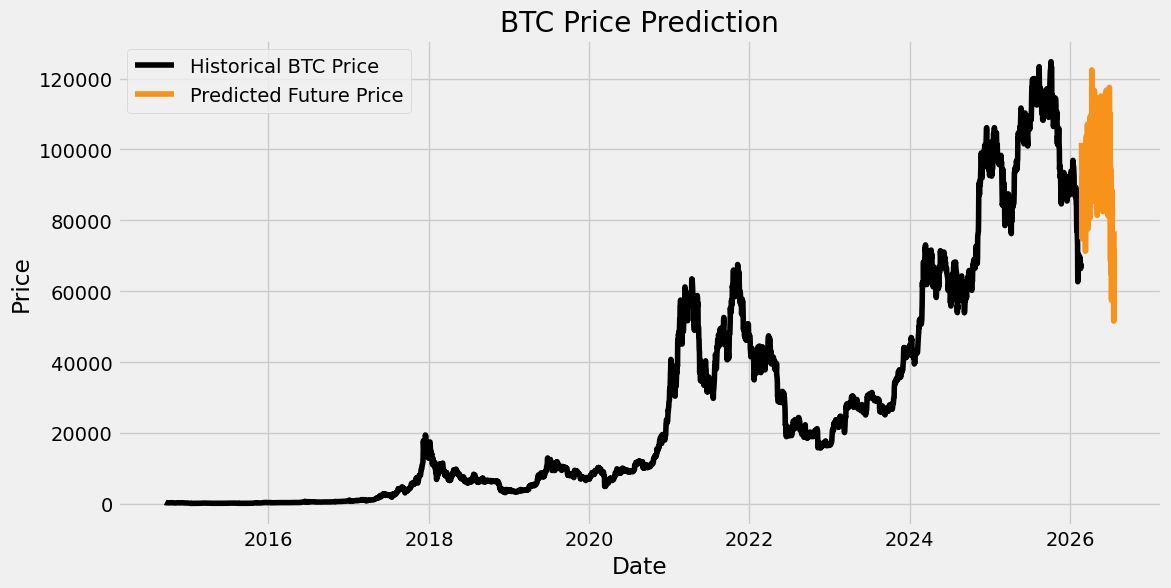

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Historical BTC Price', color='black')
plt.plot(future_dates, future_predictions, label='Predicted Future Price', linestyle='-', color='#F7931A')
plt.title('BTC Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.show()